<a href="https://colab.research.google.com/github/gjeyaraghunath-lang/STUDENT-PERFORMANCE-ANALYTICS/blob/main/STUDENT%20PROGRAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


TOP STUDENT
Kalai
Percentage: 95.25

SUBJECT AVERAGES
Math        76.6
Science     77.8
English     79.4
Computer    83.4
dtype: float64

MOST DIFFICULT SUBJECT:
Math

Prediction MAE: 4.09
Predicted Final Percentage: 81.07

CLASS STATISTICS
Average Percentage: 79.3
Highest Percentage: 95.25
Lowest Percentage: 58.75

Files Saved Successfully


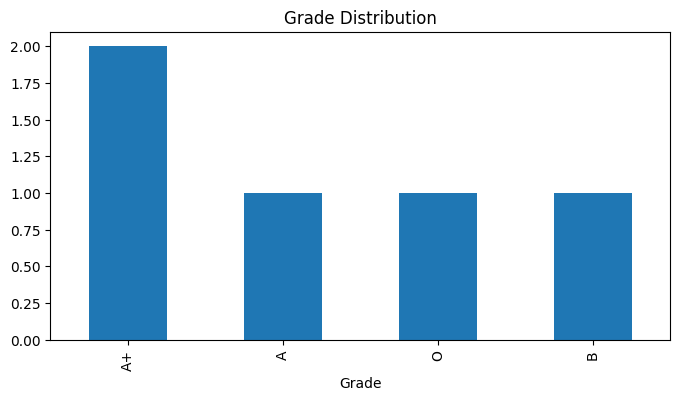

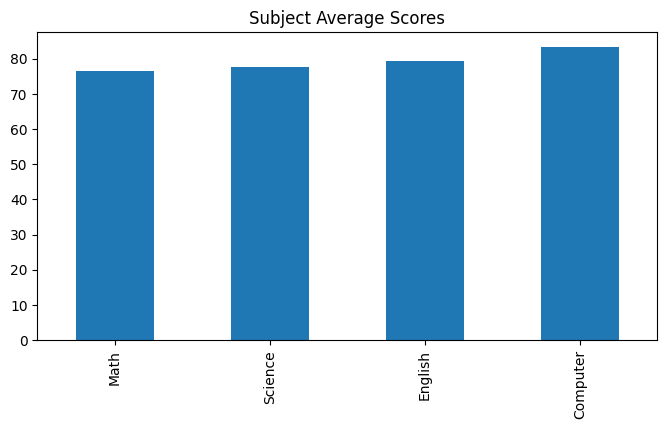

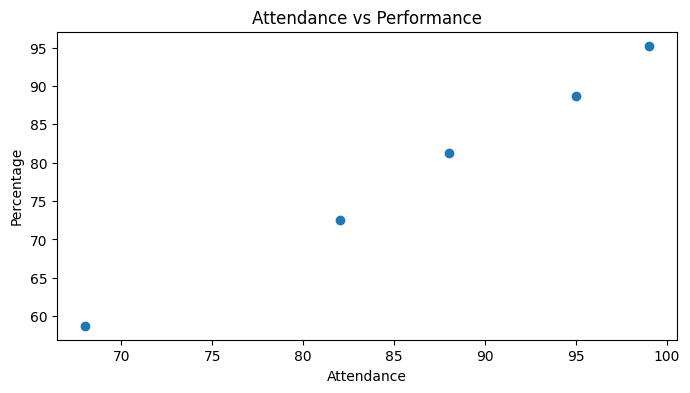


Analysis Complete
      Name  Math  Science  English  Computer  Attendance  Total  Percentage  \
0  Mathesh    85       90       88        92          95    355       88.75   
1     Guna    70       65       75        80          82    290       72.50   
2    Kalai    95       92       96        98          99    381       95.25   
3      Ari    55       60       58        62          68    235       58.75   
4    Naren    78       82       80        85          88    325       81.25   

  Grade  GPA Result  Rank Attendance_Status       Risk    Segment  
0    A+    9   Pass   2.0              Good   Low Risk  Excellent  
1     A    8   Pass   4.0              Good   Low Risk       Good  
2     O   10   Pass   1.0              Good   Low Risk  Excellent  
3     B    6   Pass   5.0               Low  High Risk    Average  
4    A+    9   Pass   3.0              Good   Low Risk       Good  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# ==========================
# CREATE DATASET IN PYTHON
# ==========================

data = {
    "Name": ["Mathesh", "Guna", "Kalai", "Ari", "Naren"],
    "Math": [85, 70, 95, 55, 78],
    "Science": [90, 65, 92, 60, 82],
    "English": [88, 75, 96, 58, 80],
    "Computer": [92, 80, 98, 62, 85],
    "Attendance": [95, 82, 99, 68, 88]
}

df = pd.DataFrame(data)

subjects = ["Math", "Science", "English", "Computer"]

# ==========================
# TOTAL & PERCENTAGE
# ==========================

df["Total"] = df[subjects].sum(axis=1)
df["Percentage"] = df["Total"] / len(subjects)

# ==========================
# GRADE CALCULATION
# ==========================

def grade(p):
    if p >= 90:
        return "O"
    elif p >= 80:
        return "A+"
    elif p >= 70:
        return "A"
    elif p >= 60:
        return "B+"
    elif p >= 50:
        return "B"
    elif p >= 40:
        return "C"
    else:
        return "F"

df["Grade"] = df["Percentage"].apply(grade)

# ==========================
# GPA
# ==========================

grade_points = {
    "O": 10,
    "A+": 9,
    "A": 8,
    "B+": 7,
    "B": 6,
    "C": 5,
    "F": 0
}

df["GPA"] = df["Grade"].map(grade_points)

# ==========================
# RESULT
# ==========================

df["Result"] = np.where(df["Percentage"] >= 40, "Pass", "Fail")

# ==========================
# RANKING
# ==========================

df["Rank"] = df["Percentage"].rank(
    ascending=False,
    method="dense"
)

# ==========================
# ATTENDANCE
# ==========================

df["Attendance_Status"] = np.where(
    df["Attendance"] >= 75,
    "Good",
    "Low"
)

# ==========================
# RISK DETECTION
# ==========================

def risk(row):
    if row["Attendance"] < 75 or row["Percentage"] < 45:
        return "High Risk"
    elif row["Percentage"] < 60:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk"] = df.apply(risk, axis=1)

# ==========================
# TOP STUDENT
# ==========================

top = df.loc[df["Percentage"].idxmax()]

print("\nTOP STUDENT")
print(top["Name"])
print("Percentage:", round(top["Percentage"], 2))

# ==========================
# SUBJECT ANALYSIS
# ==========================

subject_avg = df[subjects].mean()

print("\nSUBJECT AVERAGES")
print(subject_avg)

print("\nMOST DIFFICULT SUBJECT:")
print(subject_avg.idxmin())

# ==========================
# SEGMENTATION
# ==========================

def segment(score):
    if score >= 85:
        return "Excellent"
    elif score >= 70:
        return "Good"
    elif score >= 55:
        return "Average"
    else:
        return "Weak"

df["Segment"] = df["Percentage"].apply(segment)

# ==========================
# MACHINE LEARNING
# ==========================

X = df[["Attendance", "Math", "Science", "English"]]
y = df["Percentage"]

if len(df) >= 5:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    print("\nPrediction MAE:", round(mae, 2))

    sample = pd.DataFrame(
        [[85, 75, 80, 70]],
        columns=["Attendance", "Math", "Science", "English"]
    )

    future_score = model.predict(sample)

    print(
        "Predicted Final Percentage:",
        round(future_score[0], 2)
    )

# ==========================
# CLASS STATISTICS
# ==========================

print("\nCLASS STATISTICS")
print("Average Percentage:", round(df["Percentage"].mean(), 2))
print("Highest Percentage:", round(df["Percentage"].max(), 2))
print("Lowest Percentage:", round(df["Percentage"].min(), 2))

# ==========================
# EXPORT FILES
# ==========================

df.to_csv("Final_Analytics_Output.csv", index=False)
df.to_excel("Student_Analytics_Report.xlsx", index=False)

print("\nFiles Saved Successfully")

# ==========================
# CHARTS
# ==========================

plt.figure(figsize=(8, 4))
df["Grade"].value_counts().plot(kind="bar")
plt.title("Grade Distribution")
plt.show()

plt.figure(figsize=(8, 4))
subject_avg.plot(kind="bar")
plt.title("Subject Average Scores")
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(df["Attendance"], df["Percentage"])
plt.xlabel("Attendance")
plt.ylabel("Percentage")
plt.title("Attendance vs Performance")
plt.show()

print("\nAnalysis Complete")
print(df.head())